[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bernardorivas/wael/blob/main/notebooks/example4_mixed_3network.ipynb)

# Example 4. Three-gene regulatory network

Given a parameter sample in DSGRN region 2472287, this notebook simulates a three-gene regulatory network as a Hill system and infers the parameters back, noise-free, with least squares and a PINN. Recovery is evaluated by DSGRN region membership.

In [16]:
# %pip install -q DSGRN
# %pip install -q tqdm git+https://github.com/marciogameiro/DSGRN_utils.git

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.stats import qmc
import torch, torch.nn as nn
import DSGRN, DSGRN_utils
np.set_printoptions(precision=3, suppress=True)

# Train on a GPU when one is available: CUDA on Colab, MPS on Apple silicon, otherwise CPU.
# Note that MPS is single precision only, so CUDA is set to float32 for reproducibility.
if torch.cuda.is_available():
    DEVICE, TORCH_DTYPE = torch.device('cuda'), torch.float32
elif torch.backends.mps.is_available():
    DEVICE, TORCH_DTYPE = torch.device('mps'), torch.float32
else:
    DEVICE, TORCH_DTYPE = torch.device('cpu'), torch.float64
torch.set_default_dtype(TORCH_DTYPE)
print('torch device:', DEVICE, '| dtype:', TORCH_DTYPE)

torch device: mps | dtype: torch.float32


In [ ]:
# ---- config: single source of truth for every hyperparameter ----
from dataclasses import dataclass

@dataclass
class HParams:
    # model
    HIDDEN_WIDTH: int = 64
    DEPTH: int = 4
    FOURIER_K: int = 0          # 0 = no Fourier feature map
    # optimizer (AdamW; WEIGHT_DECAY=0 => plain Adam. Decay never touches `raw`.)
    LEARNING_RATE: float = 2e-3
    WEIGHT_DECAY: float = 0.0
    MAX_EPOCHS: int = 15000
    LBFGS_ITERS: int = 0        # 0 = skip L-BFGS phase
    GRAD_CLIP_NORM: float = 10.0  # 0 disables
    # loss weights
    W_DATA: float = 50.0
    W_PHYS: float = 10.0
    W_IC: float = 1.0
    # least squares
    LS_N_STARTS: int = 6
    # sweep
    NOISE_LEVELS: tuple = (0.0, 0.01, 0.05, 0.10, 0.25, 0.50)
    N_TRIALS: int = 1
    SEED_NOISE_BASE: int = 100
    SEED_INIT_BASE: int = 0

HP = HParams()
M = 3

### Hill functions

The production is built from Hill functions
\begin{equation}
f^+(x,L,U,\theta,d) = L + (U-L) \frac{x^d}{x^d+\theta^d}, \quad
f^-(x,L,U,\theta,d) = L + (U-L) \frac{\theta^d}{x^d+\theta^d}
\end{equation}
where `L` and `U` are the lower and upper values, `theta` is a threshold, and `d` is the steepness. This network mixes activation (`f+`) and repression (`f-`), and each gene's production is a multilinear combination of its incoming Hill factors.

We define `hill_act` and `hill_rep` below, both in NumPy for simulation and in torch for the PINN's physics loss.

In [19]:
# --- Hill production functions: smooth switches (gamma normalized to 1) ---
def hill_act(x, L, U, th, d):   # activating: low L -> high U as x rises
    xd = np.power(x, d); td = np.power(th, d)
    return L + (U - L) * xd / (td + xd)

def hill_rep(x, L, U, th, d):   # repressing: high U -> low L as x rises
    xd = np.power(x, d); td = np.power(th, d)
    return L + (U - L) * td / (td + xd)

In [20]:
# --- the same two functions in torch (used inside the network's physics loss) ---
def hill_act_t(x, L, U, th, d):
    xd = x.clamp(min=1e-9).pow(d); td = th.pow(d)
    return L + (U - L) * xd / (td + xd)

def hill_rep_t(x, L, U, th, d):
    xd = x.clamp(min=1e-9).pow(d); td = th.pow(d)
    return L + (U - L) * td / (td + xd)

## 1. Model and DSGRN region (node 2472287)

The network is

$$\dot{x}_1=-x_1+f^+(x_1)\,f^-(x_2)\,f^-(x_3),\quad
  \dot{x}_2=-x_2+f^-(x_1)\,f^+(x_2),\quad
  \dot{x}_3=-x_3+f^-(x_2)\,f^+(x_3),$$

with DSGRN specification `1 : (1)(~2)(~3)`, `2 : (~1)(2)`, `3 : (~2)(3)` which yields seven tuples `(L, U, theta)`. 

The ground truth parameters are in the parameter region 2472287, with membership tested via DSGRN's `par_index_from_sample`.

In [21]:
NET_SPEC = "1 : (1)(~2)(~3)\n2 : (~1)(2)\n3 : (~2)(3)\n"
_net = DSGRN.Network(NET_SPEC); _pg = DSGRN.ParameterGraph(_net)
TARGET = 2472287
GAMMA, DATA_D = 1.0, 15.0

# seven edges,, each edge's sign, and each node's inputs
EDGES   = [(0,0),(1,0),(2,0),(0,1),(1,1),(1,2),(2,2)]
SIGN    = {(0,0):'+',(1,0):'-',(2,0):'-',(0,1):'-',(1,1):'+',(1,2):'-',(2,2):'+'}
FACTORS = {0:[(0,0),(1,0),(2,0)], 1:[(0,1),(1,1)], 2:[(1,2),(2,2)]}
KEYS    = [f'{c}{i}{j}' for (i,j) in EDGES for c in 'LUT']

_L  = np.array([[0.979,  0.6728, 0.0   ], [0.7319, 0.0952, 1.0318], [1.11,   0.0, 0.075 ]])
_U  = np.array([[1.7861, 1.8833, 0.0   ], [1.2686, 2.1213, 3.1529], [2.9441, 0.0, 2.3182]])
_Th = np.array([[1.3848, 1.937,  0.0   ], [0.9001, 0.4126, 2.0089], [5.4074, 0.0, 0.2915]])
P = {f'{c}{i}{j}': m[i,j] for c, m in [('L',_L),('U',_U),('T',_Th)] for (i,j) in EDGES}
for (i, j) in EDGES: P[f'd{i}{j}'] = DATA_D
P['g'] = GAMMA

def production(node, x, p):                  # product of the node's Hill factors
    r = 1.0
    for (i, j) in FACTORS[node]:
        f = hill_act if SIGN[(i, j)] == '+' else hill_rep
        r = r * f(x[i], p[f'L{i}{j}'], p[f'U{i}{j}'], p[f'T{i}{j}'], p[f'd{i}{j}'])
    return r

def rhs(t, x, p, g=GAMMA):
    return [-g*x[k] + production(k, x, p) for k in range(3)]

def to_matrices(p):                          # parameter dict -> DSGRN L, U, T matrices, all indexed [source, target]
    # DSGRN entry T[i,j] = gamma_i * theta_{ij} (threshold on the source x_i; gamma = 1, so T = theta).
    # Node j is tested by ordering its production {L[i,j], U[i,j]} (inputs i->j) against its
    # OUTPUT thresholds T[j,k] (edges j->k):  L_{ij} < gamma_j theta_{jk} < U_{ij}.
    L = np.zeros((3, 3)); U = np.zeros((3, 3)); T = np.zeros((3, 3))
    for (i, j) in EDGES: L[i,j], U[i,j], T[i,j] = p[f'L{i}{j}'], p[f'U{i}{j}'], p[f'T{i}{j}']
    return L, U, T
def region_of(p):                            # parameters -> DSGRN region index (-1 if outside)
    return DSGRN.par_index_from_sample(_pg, *to_matrices(p))
def in_region(p):
    return region_of(p) == TARGET

print('The parameter graph has size:', _pg.size())
print('Which region are the ground truth parameters in?', 'Region', region_of(P))

The parameter graph has size: 3600000
Which region are the ground truth parameters in? Region 2472287


## 2. Synthetic data

64 initial conditions are drawn by Latin-hypercube sampling over the state box and integrated over a long horizon. 

The data is noise-free.

box upper bounds: [8.01, 4.79, 8.77] | trajectories: 256


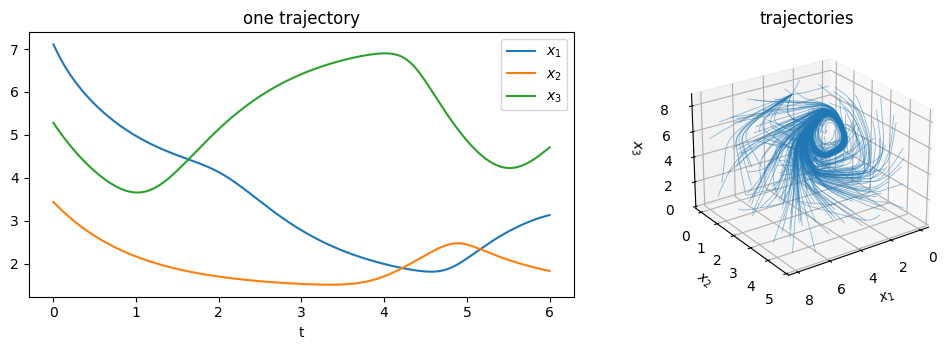

In [22]:
def max_production(p):   # upper bound for production
    U = to_matrices(p)[1]
    return np.array([np.prod([sum(U[s, k] for s in fac) for fac in _net.logic(k)]) for k in range(3)])

MARGIN = 1.2
box_hi = MARGIN * max_production(P)
n_ic   = 256
T, n = 6.0, 250
traj_color = 'tab:blue'
x0s = qmc.scale(qmc.LatinHypercube(d=3, seed=0, optimization='random-cd').random(n_ic),
                [0.0, 0.0, 0.0], box_hi).tolist()
ts, xs = [], []
for x0 in x0s:
    t = np.linspace(0.0, T, n)
    sol = solve_ivp(rhs, (0.0, T), x0, t_eval=t, args=(P,), rtol=1e-10, atol=1e-12)
    ts.append(t); xs.append(sol.y.T)
print('box upper bounds:', np.round(box_hi, 2).tolist(), '| trajectories:', n_ic)

fig = plt.figure(figsize=(11, 3.6))
ax0 = fig.add_subplot(1, 2, 1)
for k, lab in enumerate(['$x_1$', '$x_2$', '$x_3$']): ax0.plot(ts[0], xs[0][:, k], label=lab)
ax0.set_xlabel('t'); ax0.legend(); ax0.set_title('one trajectory')
axp = fig.add_subplot(1, 2, 2, projection='3d')
for y in xs: axp.plot(y[:, 0], y[:, 1], y[:, 2], color=traj_color, lw=.6, alpha=.5)
axp.view_init(elev=25, azim=55)
axp.set_xlabel('$x_1$'); axp.set_ylabel('$x_2$'); axp.set_zlabel('$x_3$')
axp.set_title('trajectories')
plt.tight_layout(); plt.show()

## 3. Least squares

Least squares fits the seven per-edge `(L, U, theta, d)` from finite-difference slopes, with `gamma` fixed. Only the twenty-one `(L, U, theta)` are scored. There is no ODE solver in the loop.

In [23]:
def ls_recover(ts, xs, g=GAMMA, n_starts=6, seed=0):
    X  = np.vstack(xs)
    DX = np.vstack([np.gradient(y, t, axis=0) for t, y in zip(ts, xs)])
    scale = np.maximum(np.std(DX, axis=0), 1e-6)

    # Per edge: L, delta (U = L + delta), T, and steepness d.
    eps = 1e-8
    upper = 25.0

    def unpack(z):
        p = {}
        for m, (i, j) in enumerate(EDGES):
            L, delta, T, d = z[4*m:4*m+4]
            p[f'L{i}{j}'] = L
            p[f'U{i}{j}'] = L + delta
            p[f'T{i}{j}'] = T
            p[f'd{i}{j}'] = d
        p['g'] = g
        return p

    def resid(z):
        p = unpack(z)
        cols = []
        for k in range(3):
            r = np.ones(X.shape[0])
            for (i, j) in FACTORS[k]:
                f = hill_act if SIGN[(i, j)] == '+' else hill_rep
                r = r * f(X[:, i], p[f'L{i}{j}'], p[f'U{i}{j}'], p[f'T{i}{j}'], p[f'd{i}{j}'])
            cols.append((DX[:, k] - (-g*X[:, k] + r)) / scale[k])
        return np.concatenate(cols)

    z_base = np.array([v for _ in EDGES for v in (0.3, 2.0 - 0.3, 1.0, 8.0)], dtype=float)
    lb = np.array([v for _ in EDGES for v in (0.0, eps, eps, 0.25)], dtype=float)
    ub = np.array([v for _ in EDGES for v in (upper, upper, upper, 80.0)], dtype=float)

    starts = [z_base]
    rng = np.random.default_rng(seed)
    for _ in range(max(0, n_starts - 1)):
        z = z_base.copy()
        for m, _edge in enumerate(EDGES):
            z[4*m + 0] = rng.uniform(0.05, 2.5)  # L
            z[4*m + 1] = rng.uniform(0.05, 4.0)  # delta = U - L
            z[4*m + 2] = rng.uniform(0.05, 6.0)  # T
            z[4*m + 3] = rng.uniform(2.0, 20.0)  # d
        starts.append(np.clip(z, lb, ub))

    best = None
    for z0 in starts:
        s = least_squares(
            resid, z0, bounds=(lb, ub), max_nfev=40000, loss='soft_l1',
            x_scale='jac', ftol=1e-10, xtol=1e-10, gtol=1e-10,
        )
        if best is None or s.cost < best.cost:
            best = s

    return unpack(best.x)

p_ls = ls_recover(ts, xs)
print('Does LS land in region', TARGET, '?', in_region(p_ls), '| region', region_of(p_ls))

Does LS land in region 2472287 ? True | region 2472287


Largest LS parameter errors


,key,edge,param,ground_truth,p_ls,signed_error,abs_error,rel_error_%
0,U22,2->2,U,2.3182,4.7241,+2.4059,2.4059,103.8
1,U12,1->2,U,3.1529,1.5472,-1.6057,1.6057,50.9
2,U20,2->0,U,2.9441,1.8376,-1.1065,1.1065,37.6
3,U10,1->0,U,1.2686,2.2279,+0.9593,0.9593,75.6
4,L10,1->0,L,0.7319,1.2855,+0.5536,0.5536,75.6
5,L12,1->2,L,1.0318,0.5064,-0.5254,0.5254,50.9
6,L20,2->0,L,1.1100,0.6928,-0.4172,0.4172,37.6
7,U11,1->1,U,2.1213,2.3817,+0.2604,0.2604,12.3
8,U01,0->1,U,1.8833,1.6771,-0.2062,0.2062,11.0
9,U00,0->0,U,1.7861,1.6292,-0.1569,0.1569,8.8


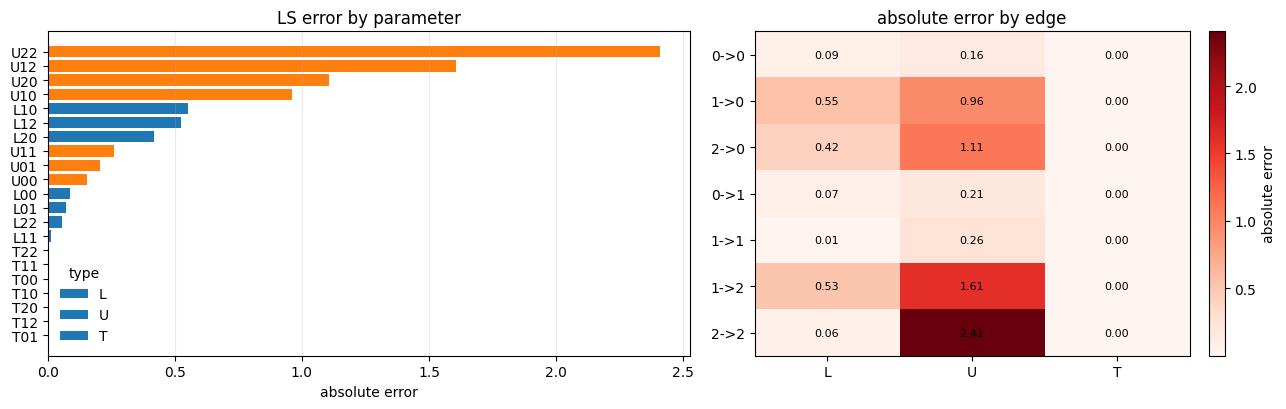

fixed scalar (gamma): {'g': {'ground_truth': 1.0, 'p_ls': 1.0, 'abs_error': 0.0}}


In [24]:
import pandas as pd
from IPython.display import display

rows = []
for k in KEYS:
    c, i, j = k[0], int(k[1]), int(k[2])
    truth = float(P[k])
    est = float(p_ls[k])
    err = est - truth
    rows.append({
        'key': k,
        'edge': f'{i}->{j}',
        'param': c,
        'ground_truth': truth,
        'p_ls': est,
        'signed_error': err,
        'abs_error': abs(err),
        'rel_error_%': 100 * abs(err) / abs(truth) if truth != 0 else np.nan,
    })

err_df = pd.DataFrame(rows)
err_sorted = err_df.sort_values('abs_error', ascending=False).reset_index(drop=True)

print('Largest LS parameter errors')
display(
    err_sorted.style
    .format({
        'ground_truth': '{:.4f}',
        'p_ls': '{:.4f}',
        'signed_error': '{:+.4f}',
        'abs_error': '{:.4f}',
        'rel_error_%': '{:.1f}',
    })
    .background_gradient(subset=['abs_error'], cmap='Reds')
)

fig, (ax0, ax1) = plt.subplots(
    1, 2, figsize=(13, 4.2),
    gridspec_kw={'width_ratios': [1.35, 1]}
)

colors = err_sorted['param'].map({
    'L': 'tab:blue',
    'U': 'tab:orange',
    'T': 'tab:green',
})

ax0.barh(err_sorted['key'], err_sorted['abs_error'], color=colors)
ax0.invert_yaxis()
ax0.set_xlabel('absolute error')
ax0.set_title('LS error by parameter')
ax0.grid(axis='x', alpha=0.25)

for param, color in {'L': 'tab:blue', 'U': 'tab:orange', 'T': 'tab:green'}.items():
    ax0.barh([], [], color=color, label=param)
ax0.legend(title='type', frameon=False)

edge_order = [f'{i}->{j}' for i, j in EDGES]
heat = err_df.pivot(index='edge', columns='param', values='abs_error').loc[edge_order, ['L', 'U', 'T']]

im = ax1.imshow(heat.values, cmap='Reds', aspect='auto')
ax1.set_xticks(range(3), heat.columns)
ax1.set_yticks(range(len(edge_order)), edge_order)
ax1.set_title('absolute error by edge')

for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        ax1.text(c, r, f'{heat.iloc[r, c]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label='absolute error')
plt.tight_layout()
plt.show()

print('fixed scalar (gamma):', {'g': {'ground_truth': P['g'], 'p_ls': p_ls['g'], 'abs_error': abs(p_ls['g'] - P['g'])}})

## 4. PINN

The surrogate `u(t, x0)` is a feed-forward network of time and the initial condition, jointly learning the seven per-edge tuples `(L, U, theta, d)`, with `gamma` fixed at 1. Only `(L, U, theta)` are scored.

In [25]:
class PINN(nn.Module):
    def __init__(self, m, param_init, T, hidden=96, depth=4, eps=1e-6, fourier_k=0):
        super().__init__()
        self.m, self.T, self.eps = m, T, eps
        self.fourier_k = fourier_k  # unused; kept only so pinn_recover can pass it uniformly
        in_dim = 1 + m

        layers, d0 = [], in_dim
        for _ in range(depth):
            layers += [nn.Linear(d0, hidden), nn.Tanh()]
            d0 = hidden
        layers += [nn.Linear(d0, m)]
        self.net = nn.Sequential(*layers)

        # Internal physical parameters are positive via softplus.
        # For each edge, train L and delta=U-L, then expose U=L+delta.
        self.raw = nn.ParameterDict()
        for (i, j) in EDGES:
            L0 = max(float(param_init[f'L{i}{j}']), eps)
            U0 = max(float(param_init[f'U{i}{j}']), L0 + eps)
            D0 = max(U0 - L0, eps)
            T0 = max(float(param_init[f'T{i}{j}']), eps)

            self.raw[f'L{i}{j}'] = nn.Parameter(self._inv_pos(L0))
            self.raw[f'D{i}{j}'] = nn.Parameter(self._inv_pos(D0))
            self.raw[f'T{i}{j}'] = nn.Parameter(self._inv_pos(T0))

        for (i, j) in EDGES:
            self.raw[f'd{i}{j}'] = nn.Parameter(self._inv_pos(param_init.get(f'd{i}{j}', DATA_D)))

    def _inv_pos(self, value):
        y = torch.tensor(
            max(float(value) - self.eps, self.eps),
            dtype=torch.get_default_dtype()
        )
        return torch.log(torch.expm1(y))

    def _pos(self, key):
        return torch.nn.functional.softplus(self.raw[key]) + self.eps

    def phys_params(self):
        p = {}
        for (i, j) in EDGES:
            L = self._pos(f'L{i}{j}')
            D = self._pos(f'D{i}{j}')
            p[f'L{i}{j}'] = L
            p[f'U{i}{j}'] = L + D
            p[f'T{i}{j}'] = self._pos(f'T{i}{j}')

        for (i, j) in EDGES:
            p[f'd{i}{j}'] = self._pos(f'd{i}{j}')
        return p

    def _feat(self, t):
        return t / self.T

    def forward(self, t, x0):
        return self.net(torch.cat([self._feat(t), x0], dim=1))


def rhs_t(x, p):
    cols = []
    for node in range(3):
        r = torch.ones_like(x[:, :1])
        for (i, j) in FACTORS[node]:
            f = hill_act_t if SIGN[(i, j)] == '+' else hill_rep_t
            r = r * f(x[:, i:i+1], p[f'L{i}{j}'], p[f'U{i}{j}'], p[f'T{i}{j}'], p[f'd{i}{j}'])
        cols.append(-x[:, node:node+1] + r)
    return torch.cat(cols, dim=1)


def build_tensors(ts, xs, x0s):
    t_d  = np.concatenate([t[:, None] for t in ts])
    x_d  = np.vstack(xs)
    x0_d = np.vstack([np.tile(x0, (len(t), 1)) for x0, t in zip(x0s, ts)])
    t_ic = np.zeros((len(x0s), 1))
    x_ic = np.array(x0s, dtype=float)

    to = lambda a: torch.tensor(a, dtype=torch.get_default_dtype(), device=DEVICE)
    return (to(t_d), to(x0_d), to(x_d), to(t_ic), to(x_ic))


def fit_pinn(model, data, rhs_t, hp, log=0):
    t_d, x0_d, x_d, t_ic, x_ic = data
    def total_loss():
        loss_data = ((model(t_d, x0_d) - x_d)**2).mean()
        tc = t_d.clone().requires_grad_(True)
        u = model(tc, x0_d)
        grads = [torch.autograd.grad(u[:, j].sum(), tc, create_graph=True)[0]
                 for j in range(model.m)]
        du = torch.cat(grads, dim=1)
        loss_phys = ((du - rhs_t(u, model.phys_params()))**2).mean()
        loss_ic = ((model(t_ic, x_ic) - x_ic)**2).mean()
        return hp.W_DATA*loss_data + hp.W_PHYS*loss_phys + hp.W_IC*loss_ic
    # decoupled decay: only network weights, never the raw physical params
    opt = torch.optim.AdamW(
        [{'params': model.net.parameters(), 'weight_decay': hp.WEIGHT_DECAY},
         {'params': model.raw.parameters(), 'weight_decay': 0.0}],
        lr=hp.LEARNING_RATE)
    for it in range(hp.MAX_EPOCHS):
        opt.zero_grad(); loss = total_loss(); loss.backward()
        if hp.GRAD_CLIP_NORM > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), hp.GRAD_CLIP_NORM)
        opt.step()
        if log and it % log == 0:
            print(f'  step {it:5d}  loss {loss.item():.2e}')
    if hp.LBFGS_ITERS > 0:
        lb = torch.optim.LBFGS(model.parameters(), max_iter=hp.LBFGS_ITERS,
                               line_search_fn='strong_wolfe')
        lb.step(lambda: (lb.zero_grad(), total_loss().backward(), total_loss())[-1])
    return model

In [26]:
init = {k: ({'L': 0.3, 'U': 2.0, 'T': 1.0}[k[0]]) for k in KEYS}
init.update({f'd{i}{j}': DATA_D for (i, j) in EDGES})

In [27]:
torch.manual_seed(0)

model = PINN(
    m=M,
    param_init=init,
    T=T,
    hidden=HP.HIDDEN_WIDTH,
    depth=HP.DEPTH,
    fourier_k=HP.FOURIER_K,
).to(DEVICE)

model = fit_pinn(
    model,
    build_tensors(ts, xs, x0s),
    rhs_t,
    HP,
    log=1000,
)

pp = {k: float(v.detach().cpu()) for k, v in model.phys_params().items()}

print('PINN lands in region', TARGET, '?', in_region(pp), '| region', region_of(pp))
print('all U > L:', all(pp[f'U{i}{j}'] > pp[f'L{i}{j}'] for i, j in EDGES))

  step     0  loss 7.78e+02
  step  1000  loss 6.43e+00
  step  2000  loss 2.15e+00
  step  3000  loss 1.14e+00
  step  4000  loss 8.25e-01
  step  5000  loss 6.35e-01
  step  6000  loss 5.75e-01
  step  7000  loss 5.26e-01
  step  8000  loss 4.68e-01
  step  9000  loss 4.43e-01
  step 10000  loss 4.77e-01
  step 11000  loss 3.86e-01
  step 12000  loss 3.82e-01
  step 13000  loss 3.88e-01
  step 14000  loss 3.63e-01
PINN lands in region 2472287 ? False | region 2768882
all U > L: True


## 5. Region recovery across noise

For each noise level (a percentage of a characteristic edge gap), least squares and the PINN are each refit over independent noisy datasets, and the fraction landing in region 2472287 is reported.

In [28]:
# ---- noise model (bounded uniform, scaled by a characteristic edge gap) ----
def add_noise(y, ub_frac, scale, rng):
    yn = y + rng.uniform(-ub_frac*scale, ub_frac*scale, size=y.shape)
    return np.clip(yn, 0.0, None)   # concentrations stay non-negative

# ---- unified sweep + reporting (notebook-independent) ----
def run_sweep(recover_fn, clean_xs, scale, membership_fn, hp):
    """recover_fn(xs_noisy, init_seed) -> params dict. Returns {noise: hit_count}."""
    rates = {}
    for ub in hp.NOISE_LEVELS:
        hits = 0
        for k in range(hp.N_TRIALS):
            rng = np.random.default_rng(hp.SEED_NOISE_BASE + k)
            xs_n = [add_noise(y, ub, scale, rng) for y in clean_xs]
            hits += int(membership_fn(recover_fn(xs_n, hp.SEED_INIT_BASE + k)))
        rates[ub] = hits
    return rates

def sweep_table(pinn_rates, ls_rates, hp, title):
    N = hp.N_TRIALS
    print(f'{"noise":>6} | {"PINN":>8} | {"LS":>8}')
    px, pp_, lp_ = [], [], []
    for ub in hp.NOISE_LEVELS:
        pr, lr = pinn_rates[ub], ls_rates[ub]
        print(f'{ub*100:>5.0f}% | {pr:>3}/{N} | {lr:>3}/{N}')
        px.append(ub*100); pp_.append(pr/N); lp_.append(lr/N)
    plt.plot(px, pp_, 'o-', label='PINN')
    plt.plot(px, lp_, 's--', label='least squares')
    plt.xlabel('noise upper bound (%)'); plt.ylabel('region-recovery rate')
    plt.ylim(-0.05, 1.05); plt.legend(); plt.title(title); plt.show()

def pinn_recover(xs_n, init_seed):
    torch.manual_seed(init_seed)
    model = PINN(m=M, param_init=init, T=T,
                 hidden=HP.HIDDEN_WIDTH, depth=HP.DEPTH,
                 fourier_k=HP.FOURIER_K).to(DEVICE)
    model = fit_pinn(model, build_tensors(ts, xs_n, x0s), rhs_t, HP)
    return {k: float(v.detach()) for k, v in model.phys_params().items()}

In [ ]:
gap = min(abs(P[f'U{i}{j}'] - P[f'L{i}{j}']) for i, j in EDGES)   # characteristic edge gap, analogous to Ex1/Ex3
ls_rates   = run_sweep(lambda xs_n, s: ls_recover(ts, xs_n, n_starts=HP.LS_N_STARTS), xs, gap, in_region, HP)
pinn_rates = run_sweep(pinn_recover, xs, gap, in_region, HP)
sweep_table(pinn_rates, ls_rates, HP, 'Three-gene network: region recovery vs noise')

## Topological validation (DSGRN)

There are two criteria per recovered parameter set: exact DSGRN region equality, and Morse graph isomorphism. Region equality implies isomorphic Morse graphs, so the second criterion is weaker than the first.

We compare the recovered and target Morse graphs via `par_index_from_sample`, `DSGRN_utils.ConleyMorseGraph`, and `DSGRN.isomorphic_morse_graphs`. For the target region we also plot the Morse sets in state space with `DSGRN_utils.PlotMorseSets` and the Conley-Morse graph with `DSGRN_utils.PlotMorseGraph`.

In [ ]:
_mg = {}
def conley_morse(idx):          # region index -> Conley-Morse graph (cached)
    if idx not in _mg:
        _mg[idx] = DSGRN_utils.ConleyMorseGraph(_pg.parameter(idx))[0]
    return _mg[idx]
def morse_recovers(idx, target=TARGET):   # same Conley-Morse graph up to label-preserving iso
    return idx >= 0 and DSGRN.isomorphic_morse_graphs(conley_morse(idx), conley_morse(target))

dg = DSGRN.DomainGraph(_pg.parameter(TARGET)); dec = DSGRN.MorseDecomposition(dg.digraph())
print('Morse graph of node', TARGET, ':', DSGRN.MorseGraph(dg, dec).stringify())
_cmg = DSGRN_utils.ConleyMorseGraph(_pg.parameter(TARGET))

In [ ]:
DSGRN_utils.PlotMorseSets(*_cmg, proj_dims=[0, 1])

In [ ]:
DSGRN_utils.PlotMorseGraph(_cmg[0])

In [ ]:
for name, p in [('least squares', p_ls), ('PINN', pp)]:
    idx = region_of(p)
    print(f'{name:>14}: region {idx:>8} | exact region match: {idx == TARGET!s:>5} '
          f'| Morse/Conley match: {morse_recovers(idx)!s:>5}')